# Lab Task: NYC Flights

### Name :

In [3]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt

## 1. Read Data

In [5]:
# Read data 'nyc_flights.csv'
df = pd.read_csv('/Users/adfz088/Documents/GitHub/BA1200/Tutorial3/nyc_flights.csv')
df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


Q: how many rows in this dataset?

In [3]:
len(df)

336776

# Data Dictionary

1. year - Year of Flight
2. month - Month of Flight
3. day - Day (number of Flight)
4. dep_time - Departure Time
5. sched_dep_time - Scheduled Departure Time
6. dep_delay - Departure Delay (in Minutes)
7. arr_time - Arrival Time
8. sched_arr_time - Scheduled Arrival Time
9. arr_delay - Arrival Delay (in Minutes)
10. carrier- Carrier Details of Flight
11. flight - Flight Name
12. tailnum - Tailnumber of Flight
13. origin - Origin of Flight
14. dest - Destination Airport Name
15. air_time - Air Time (Time in Air - travel Time ( in minutes) )
16. distance - Distance (assuming in miles?)
17. hour - Hour
18. minute - minute
19. time_hour - time hour

Q; In practice, how would you find details of your dataset as you see the data dictionary above? 

(ANS) 

Q: how many airports in NYC ? Name them from the dataset (you can google it, too)

(ANS)

## 2. Check missing values

In [11]:
# check missing values in all columns
df.isnull().sum()

year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

Q: Which column has the largest percentage of missing values relative to the total number of its rows?

(ANS)

In [6]:
#Drop Null Values
df.dropna(axis=0,how ='any', inplace=True)

#Drop the columns that i dont need for my analysis to reduce the processing time/power
df.drop(axis=1,columns=['sched_dep_time','sched_arr_time','time_hour'],inplace=True)

* Comments : there are other ways to deal with missing values such that you can 'impute' null/missing values with aveage or previous values  (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html)


In [5]:
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute
0,2013,1,1,517.0,2.0,830.0,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15
1,2013,1,1,533.0,4.0,850.0,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29
2,2013,1,1,542.0,2.0,923.0,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0


In [9]:
len(df)

327346

## 3. Getting an interaction chart

### Hint 
    1) Please be aware that the interaction chart requires exclusively numerical columns.
    2) Use seaborn and sns.heatmap (https://seaborn.pydata.org/generated/seaborn.heatmap.html)


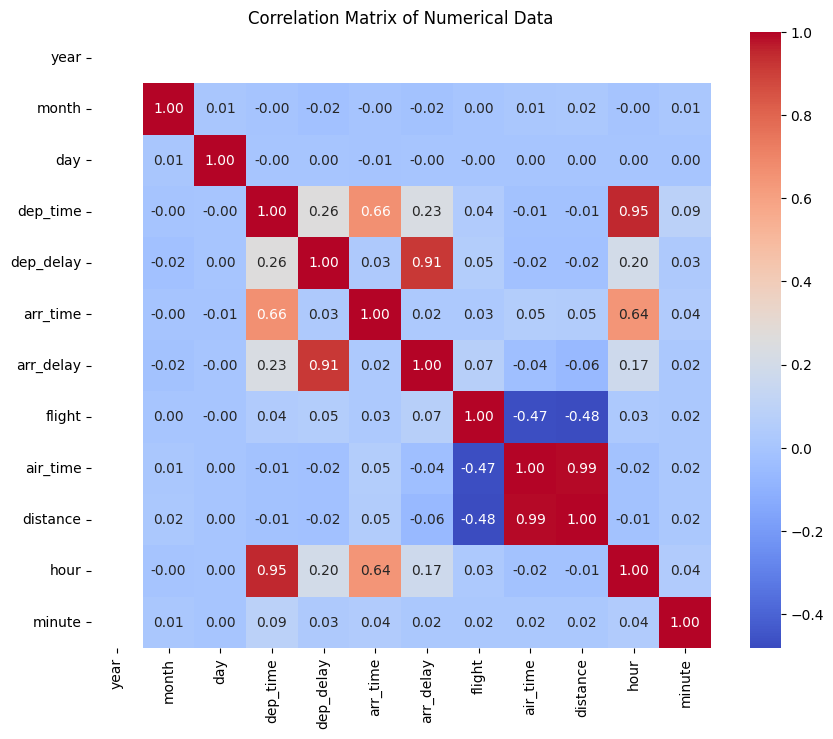

In [6]:
%matplotlib inline

import seaborn as sns

# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix for numerical data
correlation_matrix = numerical_df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Data')
plt.show()

Q : what columns have high interactions ?

(ANS)

## 4. EDA using Profiling Report

You can do EDA all at once with ProfilingReport!

In [12]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [9]:
from ydata_profiling import ProfileReport

/Users/adfz088/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Profiling : https://docs.profiling.ydata.ai/latest/
profile = ProfileReport(df)

profile.to_file("your_report.html")



Export report to file: 100%|██████████| 1/1 [00:00<00:00, 120.15it/s]


Q: Does this result have the same result from what you have done above? 

(ANS)

## 5. Visualize the comparison of flight volumes departing from EWR, JFK, and LGA

Ref: airport code (https://www.world-airport-codes.com/us-top-40-airports.html)


Text(0.5, 0, 'Airport')

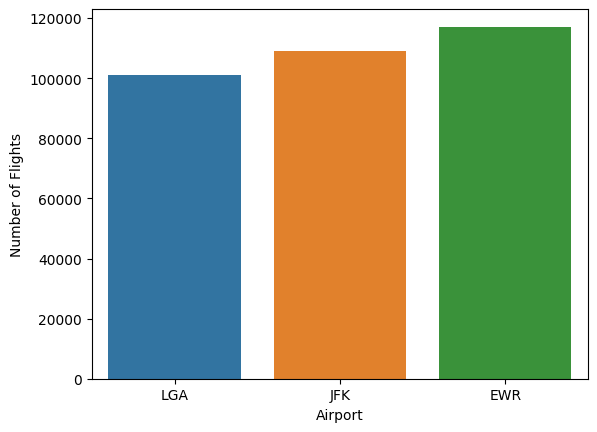

In [13]:
import seaborn as sns

dt=df.groupby(by='origin').count().reset_index().sort_values(by='year')
sns.barplot(x="origin", y="year", data=dt, hue = "origin")
plt.ylabel("Number of Flights")
plt.xlabel("Airport")


Q: Explain why you chose the chart above and what airport has highest number of flights taking off from ?

(ANS)

## 6. Average Departure delay from airports

In [17]:
numerical_df = df.select_dtypes(include=['number'])  # 숫자형 데이터만 선택
grouped_df = numerical_df.groupby(by=df['origin']).mean().reset_index()


Text(0.5, 0, 'Airport')

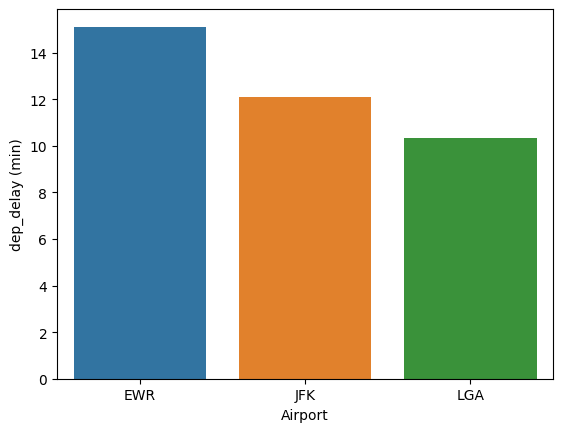

In [46]:
sns.barplot(x="origin", y="dep_delay", data=grouped_df, hue = "origin")
plt.ylabel("dep_delay (min)")
plt.xlabel("Airport")

what airport has highest departure delay ? Any relationship with 'No. 5's results? 

(ANS)

## 7. Visualize Flight Carrier Frequency

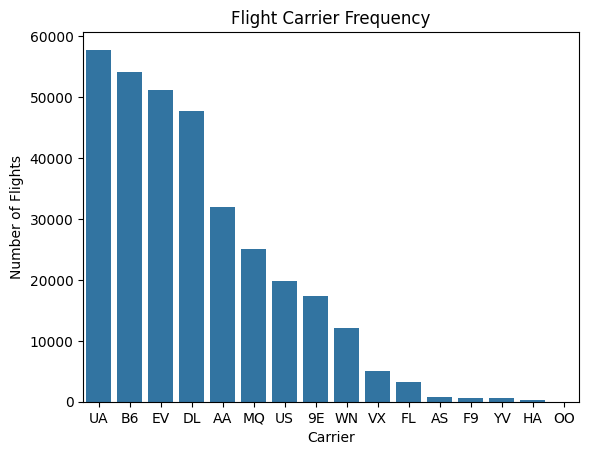

In [21]:
# Count the frequency of each carrier
carrier_counts = df['carrier'].value_counts()

sns.barplot(data=carrier_counts)

# Create bar chart
plt.title('Flight Carrier Frequency')
plt.xlabel('Carrier')
plt.ylabel('Number of Flights')
plt.show()

Q: what are the top3 frequent flight carrers?

(ANS)

## 7. Scatter plot for Departure delay vs arrival delay

Text(0, 0.5, 'arr_delay')

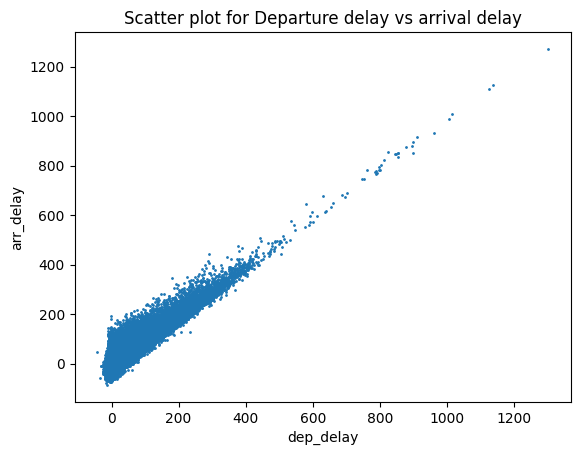

In [66]:
plt.scatter(df['dep_delay'], df['arr_delay'], s = 1)
plt.title('Scatter plot for Departure delay vs arrival delay')
plt.xlabel('dep_delay')
plt.ylabel('arr_delay')

do you find anything suspicious from the dataset? 

(ANS) 

In [72]:
df[df['dep_delay']<0].sort_values(by = 'dep_delay')

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
89673,2013,12,7,2040.0,2123,-43.0,40.0,2352,48.0,B6,97,N592JB,JFK,DEN,265.0,1626,21,23,2013-12-08T02:00:00Z
113633,2013,2,3,2022.0,2055,-33.0,2240.0,2338,-58.0,DL,1715,N612DL,LGA,MSY,162.0,1183,20,55,2013-02-04T01:00:00Z
64501,2013,11,10,1408.0,1440,-32.0,1549.0,1559,-10.0,EV,5713,N825AS,LGA,IAD,52.0,229,14,40,2013-11-10T19:00:00Z
9619,2013,1,11,1900.0,1930,-30.0,2233.0,2243,-10.0,DL,1435,N934DL,LGA,TPA,139.0,1010,19,30,2013-01-12T00:00:00Z
24915,2013,1,29,1703.0,1730,-27.0,1947.0,1957,-10.0,F9,837,N208FR,LGA,DEN,250.0,1620,17,30,2013-01-29T22:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161694,2013,3,28,859.0,900,-1.0,1200.0,1224,-24.0,DL,120,N707TW,JFK,LAX,333.0,2475,9,0,2013-03-28T13:00:00Z
309828,2013,9,1,1929.0,1930,-1.0,2250.0,2250,0.0,AA,269,N3HFAA,JFK,SEA,341.0,2422,19,30,2013-09-01T23:00:00Z
309827,2013,9,1,1929.0,1930,-1.0,2230.0,2248,-18.0,B6,71,N656JB,JFK,SLC,270.0,1990,19,30,2013-09-01T23:00:00Z
161816,2013,3,28,1124.0,1125,-1.0,1303.0,1327,-24.0,EV,5277,N719EV,EWR,MSP,142.0,1008,11,25,2013-03-28T15:00:00Z


In [73]:
df[df['arr_delay']<0].sort_values(by = 'arr_delay')

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
199668,2013,5,7,1715.0,1729,-14.0,1944.0,2110,-86.0,VX,193,N843VA,EWR,SFO,315.0,2565,17,29,2013-05-07T21:00:00Z
211124,2013,5,20,719.0,735,-16.0,951.0,1110,-79.0,VX,11,N840VA,JFK,SFO,316.0,2586,7,35,2013-05-20T11:00:00Z
198763,2013,5,6,1826.0,1830,-4.0,2045.0,2200,-75.0,AA,269,N3KCAA,JFK,SEA,289.0,2422,18,30,2013-05-06T22:00:00Z
195236,2013,5,2,1947.0,1949,-2.0,2209.0,2324,-75.0,UA,612,N851UA,EWR,LAX,300.0,2454,19,49,2013-05-02T23:00:00Z
196935,2013,5,4,1816.0,1820,-4.0,2017.0,2131,-74.0,AS,7,N551AS,EWR,SEA,281.0,2402,18,20,2013-05-04T22:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130638,2013,2,22,1902.0,1900,2.0,2123.0,2124,-1.0,9E,3439,N934XJ,JFK,CVG,112.0,589,19,0,2013-02-23T00:00:00Z
182546,2013,4,19,1013.0,1015,-2.0,1211.0,1212,-1.0,US,1427,N742PS,JFK,CLT,83.0,541,10,15,2013-04-19T14:00:00Z
70999,2013,11,17,1355.0,1355,0.0,1534.0,1535,-1.0,MQ,3493,N532MQ,LGA,CLE,68.0,419,13,55,2013-11-17T18:00:00Z
182477,2013,4,19,912.0,915,-3.0,1104.0,1105,-1.0,AA,313,N599AA,LGA,ORD,121.0,733,9,15,2013-04-19T13:00:00Z


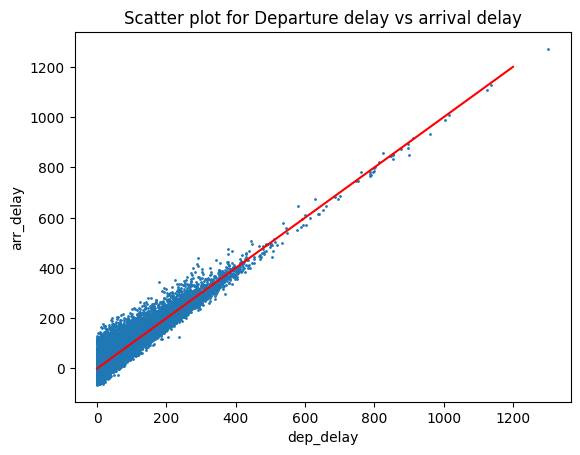

In [86]:
dfs = df[df['dep_delay']>0]
plt.scatter(dfs['dep_delay'], dfs['arr_delay'], s = 1)
plt.title('Scatter plot for Departure delay vs arrival delay')
plt.xlabel('dep_delay')
plt.ylabel('arr_delay')

x_line = np.linspace(0, 1200, 100)  # x 범위 설정
y_line = x_line  # y 계산
plt.plot(x_line, y_line, color="red", linestyle="-")  # 빨간 점선


## 8. On Time Arrival Performance of Airports

Text(0.5, 0, 'Origin Airports')

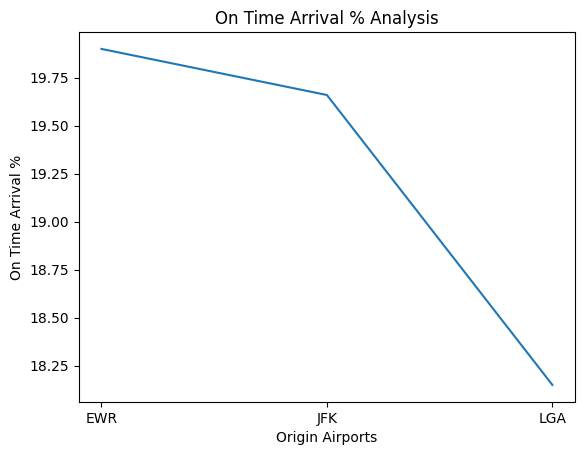

In [87]:
# Count rows of arrival on time grouped by airports
ota=(df[df["arr_delay"] <= 0].groupby("origin").count())

#
OnTimeArrivalPerc=np.round(((ota["year"]/ df["month"].count() ) * 100),decimals=2)

plt.plot(OnTimeArrivalPerc)
plt.title("On Time Arrival % Analysis")
plt.ylabel("On Time Arrival %")
plt.xlabel("Origin Airports")

Q: Share your insights from ten steps above

(ANS)

Despite of being Busiest AIRPORT - EWR ( Newark International Airport ) having maximum number of flights taking off and having high departure time delay, this airport is having good on-time arrival which means Newark International Airport is having good landing area for incoming flights - **INSIGHT**


So Airport authorities may like to improve Newark International Airport	for enhancing departure timelines to reduce departure delays further considering heavy traffic from this airport